In [1]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

# Training

In [3]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_1 = Tensor(make_moons(256, noise=0.05)[0])
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

# Sampling

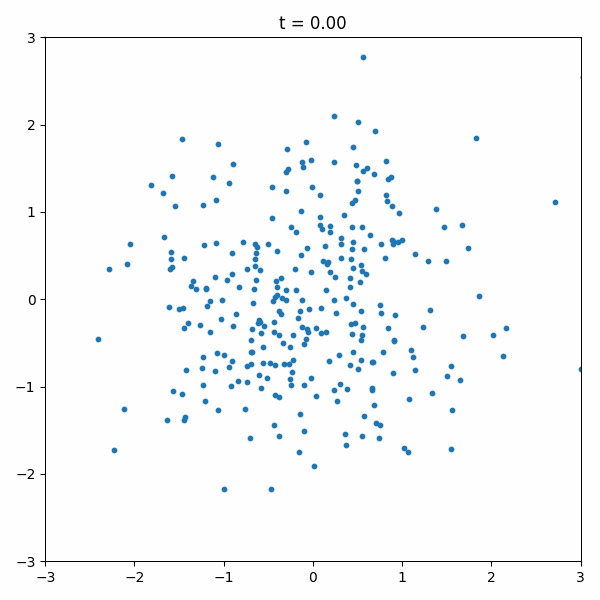

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image
%matplotlib inline

# Assuming flow is defined elsewhere with a step method
x = torch.randn(300, 2)
n_steps = 100  # Increased steps for smoother animation
time_steps = torch.linspace(0, 1.0, n_steps, dtype=torch.float32)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-3.0, 3.0)
scatter = ax.scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
title = ax.set_title(f't = {time_steps[0]:.2f}')

def update(frame):
    global x
    x = flow.step(x_t=x, t_start=time_steps[frame], t_end=time_steps[frame + 1] if frame < n_steps - 1 else time_steps[frame])
    scatter.set_offsets(x.detach().numpy())
    title.set_text(f't = {time_steps[frame]:.2f}')
    return scatter, title

ani = FuncAnimation(fig, update, frames=range(n_steps), interval=100, blit=True)
plt.tight_layout()
ani.save('flow_moons_animation.gif', writer='pillow', fps=10)
plt.close()
Image(filename='flow_moons_animation.gif')